# Notebook 2 – HD-EMG: spatial analysis

**Workflow:** load with probe → probe geometry → spatial interpolation → spatial filtering → amplitude maps

This notebook demonstrates HD-EMG analysis using all 32 channels of the NeuroNexus H32 probe.

**You will learn how to:**
1. Load data with probe geometry (channel ordering, electrode positions).
2. Build an `HDEMG` object and inspect the probe layout.
3. Interpolate to a uniform grid (required for convolution-based spatial filters).
4. Apply 2-D spatial filters (IB2, NDD) to suppress common-mode noise.
5. Generate amplitude heatmaps (RMS, PTP) and timing maps.
6. Compare spatial filters side by side.


## 1 · Imports & path setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecmuap_interface.utils.trigger import Trigger
from ecmuap_interface.core.emg_data import EMGData
from ecmuap_interface.core.HD_emg import HDEMG
from ecmuap_interface.views.HDemg_view import HDEMGView
from ecmuap_interface.probe_lib.get_probes import NeuroNexus_H32
from ecmuap_interface.utils.loaders import Ripple_to_array
from ecmuap_interface.utils.probes import make_uniform_probe_from_base
from ecmuap_interface.utils.spatial_filters import (
    unit_kernel, NDD_kernel, LDD_kernel, TDD_kernel, IB2_kernel, IR_kernel
)

DATA_FILE = Path("../data/test_emg.hdf5")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110})


## 2 · Load data with probe

`Ripple_to_array` reorders channels according to the probe's `device_channel_indices`,  
so that `data[ch]` always corresponds to the electrode at `probe.contact_positions[ch]`.


In [2]:
df    = pd.read_hdf(DATA_FILE)
probe = NeuroNexus_H32()

time    = df["time"].values
data    = Ripple_to_array(df, probe)   # (32, n_samples) – probe-ordered
trigger = Trigger(df["Tr0 "].values, time)

print(f"Probe   : {probe.get_contact_count()} contacts")
print(f"Data    : {data.shape[0]} ch × {data.shape[1]} samples")
print(f"Triggers: {len(trigger.get_events()[0])} events")


Probe   : 32 contacts
Data    : 32 ch × 242580 samples
Triggers: 60 events


## 3 · Build HDEMG and preprocess

In [3]:
emg = EMGData(data=data, time=time, trigger=trigger)

# Standard filter chain
emg.HPF(10)
emg.notch(50.0)
emg.LPF(1_000)
emg.remove_baseline()

hd = HDEMG(emg=emg, probe=probe)
print("HDEMG ready:", hd.emg.n_channels, "channels")


HDEMG ready: 32 channels


## 4 · Probe geometry

`HDEMGView` can render the physical layout of the probe.  
Each small dot is one electrode; the subplot grid mirrors the spatial arrangement.


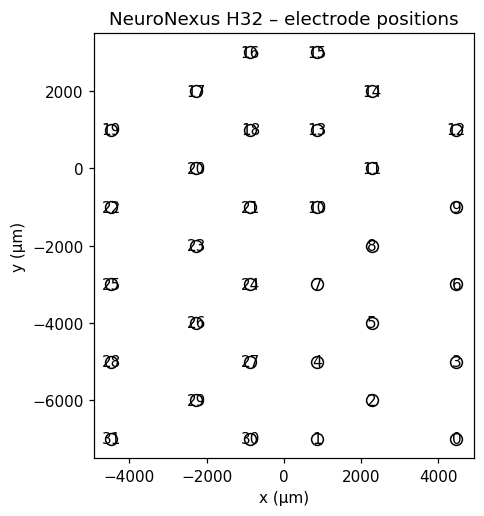

In [4]:
view_raw = HDEMGView(hd)
ax = view_raw.plot_probe(show_ids=True)
ax.set_title("NeuroNexus H32 – electrode positions")
plt.tight_layout()


### 4.1 · Multi-channel average eCMUAP (probe layout)

Each mini-plot below corresponds to one electrode, spatially arranged  
according to the probe geometry.


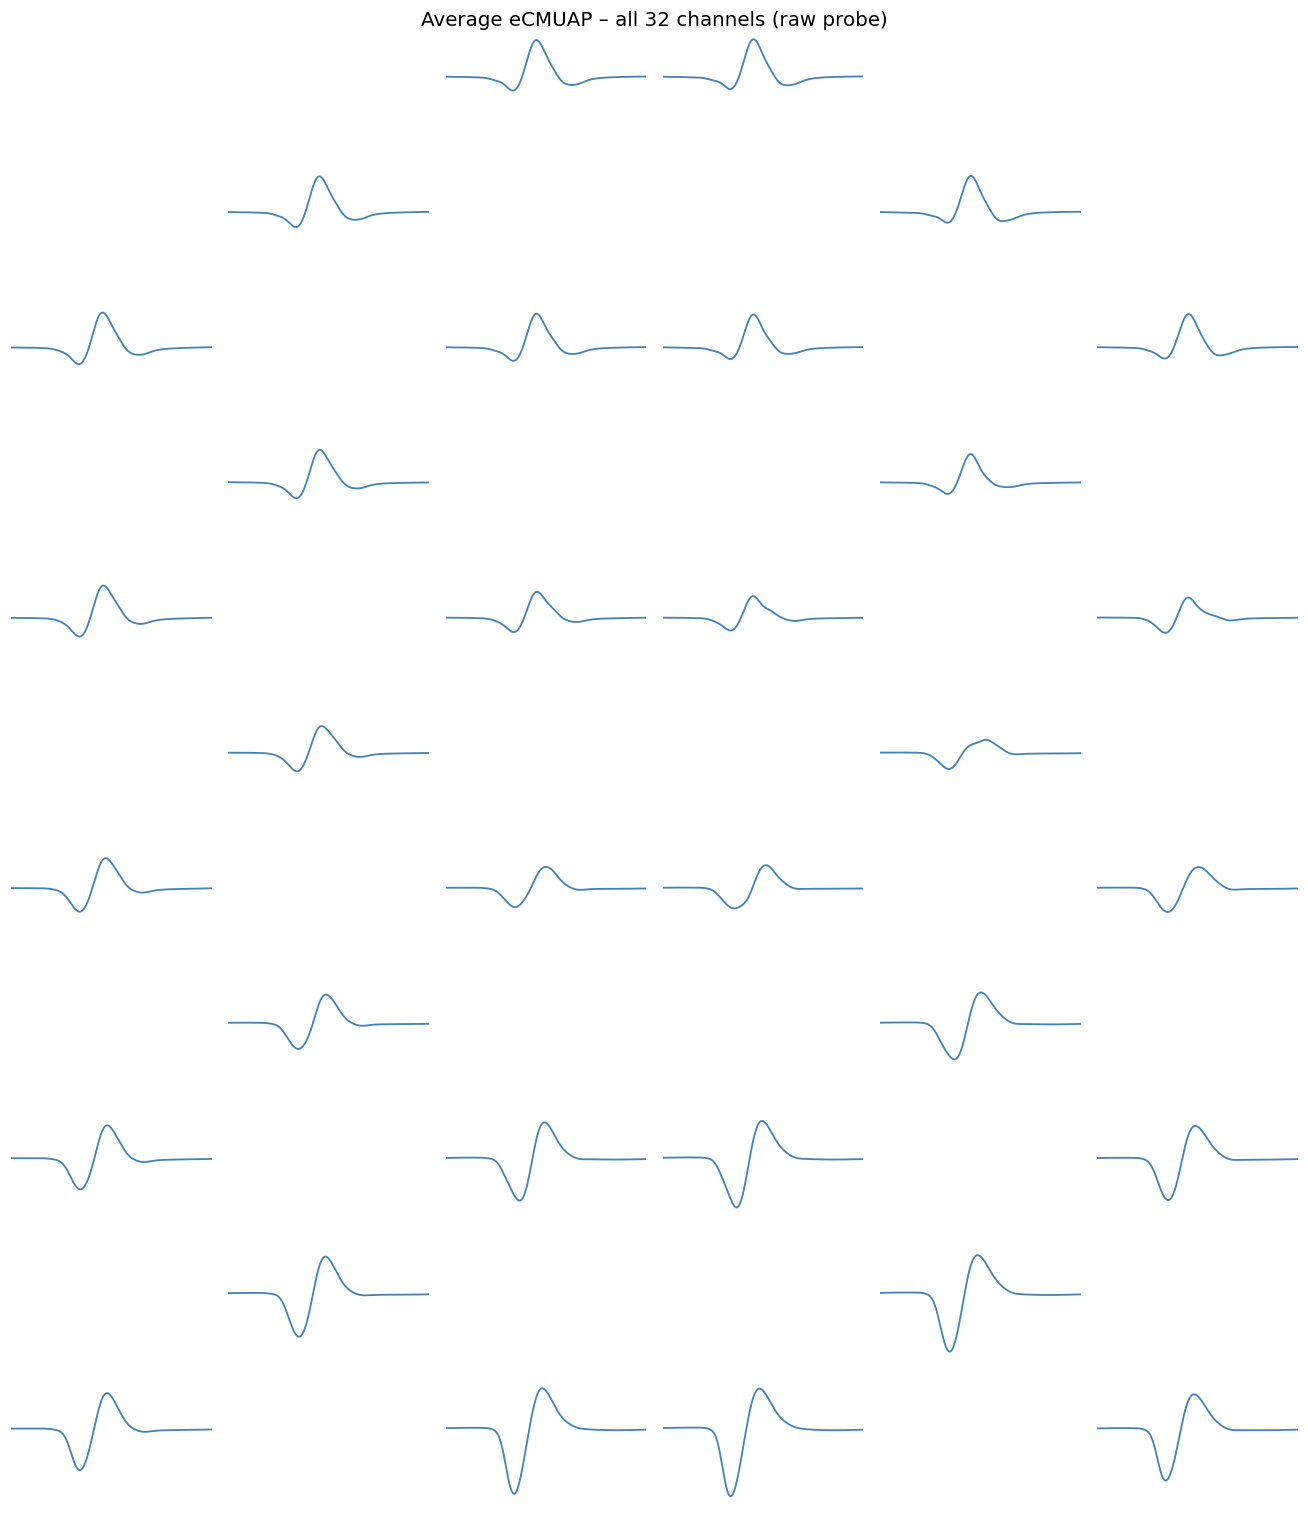

In [5]:
T_PRE, T_POST = 1e-3, 15e-3

fig, axs = view_raw.plot_avg_eCMUAP(
    T_PRE, T_POST, skip_start=3, skip_end=3,
    axis_off=True, figsize=(12, 14), lw=1.2, color="steelblue"
)
fig.suptitle("Average eCMUAP – all 32 channels (raw probe)", fontsize=13)
plt.tight_layout()


## 5 · Spatial interpolation to a uniform grid

Convolution-based spatial filters (NDD, IB2, …) require electrodes on a  
**regular Cartesian grid**.  The NeuroNexus H32 is *nearly* uniform but  
has small positional offsets.  We interpolate to a perfect grid using cubic  
`scipy.interpolate.griddata`.


In [6]:
uniform_probe = make_uniform_probe_from_base(probe)

print(f"Original probe : {probe.get_contact_count()} contacts")
print(f"Uniform grid   : {uniform_probe.get_contact_count()} contacts")
print(f"Pitch          : {uniform_probe.annotations['pitch_um']:.1f} µm")


Original probe : 32 contacts
Uniform grid   : 34 contacts
Pitch          : 1726.2 µm


In [7]:
# interpolate_to_probe returns a new EMGData on the uniform grid
emg_interp = hd.interpolate_to_probe(uniform_probe, method="cubic")
hd_interp  = HDEMG(emg=emg_interp, probe=uniform_probe)

view_interp = HDEMGView(hd_interp)
print("Interpolated HDEMG:", hd_interp.emg.n_channels, "channels on uniform grid")


Interpolated HDEMG: 34 channels on uniform grid


## 6 · 2-D spatial filtering

Spatial filters attenuate correlated noise shared across electrodes  
(e.g. common-mode movement artefact) while sharpening the spatial  
representation of localised motor unit activity.

| Kernel | Behaviour |
|--------|-----------|
| `unit_kernel` | Identity – no spatial filtering |
| `NDD_kernel` | 2-D Laplacian – best general-purpose sharpening |
| `IB2_kernel` | Weighted Laplacian – best SNR for HD-EMG |
| `LDD_kernel` | 1-D (column) second derivative |
| `TDD_kernel` | 1-D (row) second derivative |

> **Important:** `spatial_filter` is called on an `HDEMG` object and returns  
> a new `EMGData`; wrap it in a fresh `HDEMG` for downstream processing.


In [8]:
def apply_kernel(hd_obj, kernel_fn):
    """Helper: apply spatial kernel and return a new HDEMG + HDEMGView."""
    emg_filt = hd_obj.spatial_filter(kernel_fn)
    hd_filt  = HDEMG(emg=emg_filt, probe=hd_obj.probe)
    return HDEMGView(hd_filt)

view_ndd = apply_kernel(hd_interp, NDD_kernel)
view_ib2 = apply_kernel(hd_interp, IB2_kernel)

print("NDD and IB2 views ready.")


NDD and IB2 views ready.


### 6.1 · Average eCMUAP comparison: unfiltered vs IB2

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12), sharey=False)

for ax_col, (label, vw) in enumerate([
    ("Interpolated (no spatial filter)", view_interp),
    ("IB2 spatial filter", view_ib2),
]):
    # reuse _create_probe_axes for the right column
    fig_tmp, axs_tmp = vw.plot_avg_eCMUAP(
        T_PRE, T_POST, skip_start=3, skip_end=3,
        axis_off=True, figsize=(9, 12), lw=1.2
    )
    fig_tmp.suptitle(label)
    fig_tmp.tight_layout()

plt.close("all")
print("See the two separate figures above for the side-by-side comparison.")


See the two separate figures above for the side-by-side comparison.


## 7 · Amplitude heatmaps

`plot_rms_map` and `plot_ptp_map` compute per-electrode amplitude of  
the averaged eCMUAP and render a spatially interpolated colour map.


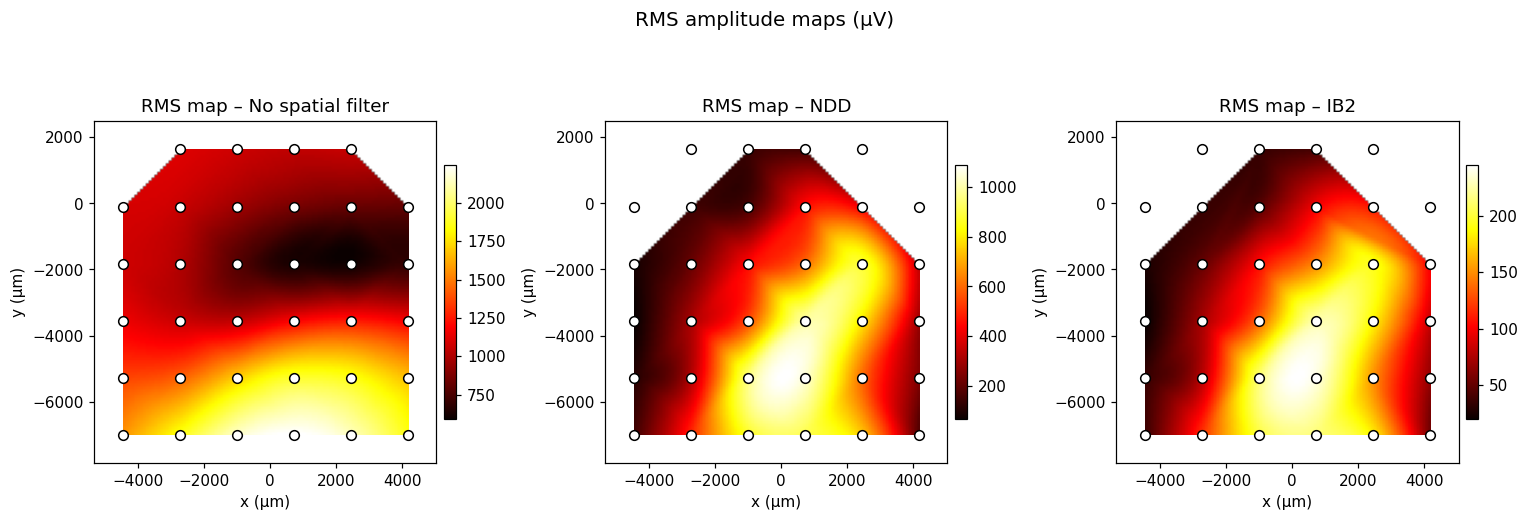

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (label, vw) in zip(axes, [
    ("No spatial filter", view_interp),
    ("NDD",               view_ndd),
    ("IB2",               view_ib2),
]):
    vw.plot_rms_map(T_PRE, T_POST, skip_start=3, skip_end=3,
                    reject=True, cmap="hot", ax=ax)
    ax.set_title(f"RMS map – {label}")

plt.suptitle("RMS amplitude maps (µV)", fontsize=13)
plt.tight_layout()


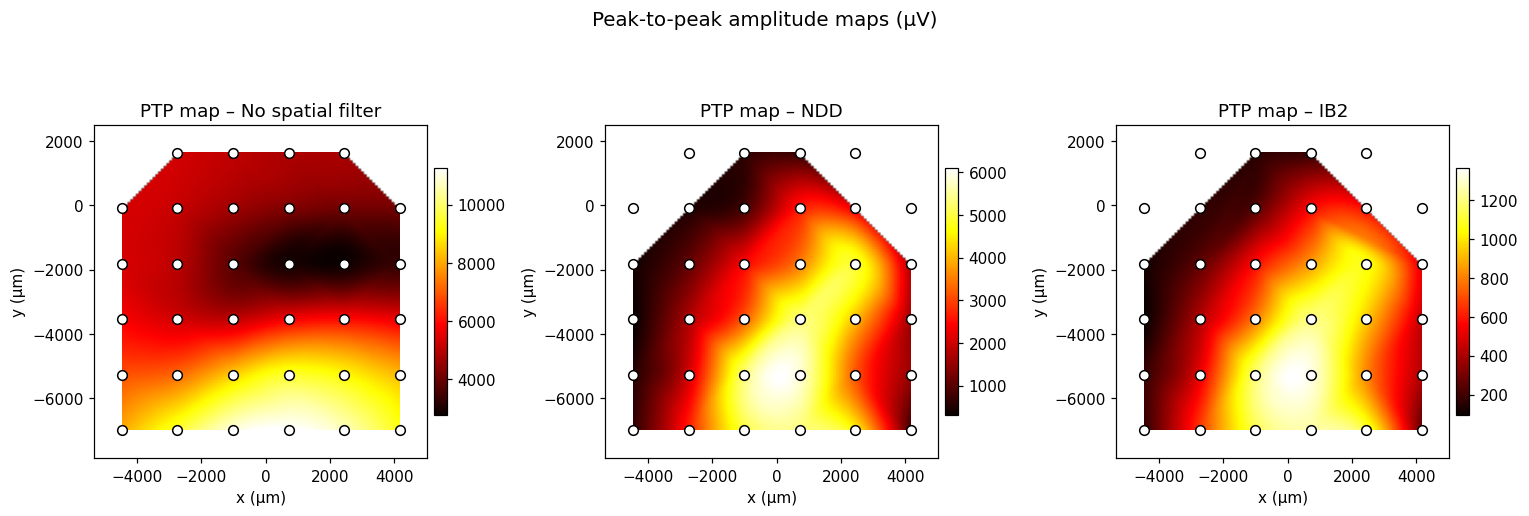

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (label, vw) in zip(axes, [
    ("No spatial filter", view_interp),
    ("NDD",               view_ndd),
    ("IB2",               view_ib2),
]):
    vw.plot_ptp_map(T_PRE, T_POST, skip_start=3, skip_end=3,
                    reject=True, cmap="hot", ax=ax)
    ax.set_title(f"PTP map – {label}")

plt.suptitle("Peak-to-peak amplitude maps (µV)", fontsize=13)
plt.tight_layout()


## 8 · Timing maps

The `latency` and `duration` maps reveal the spatial pattern of eCMUAP  
onset and duration across the muscle.


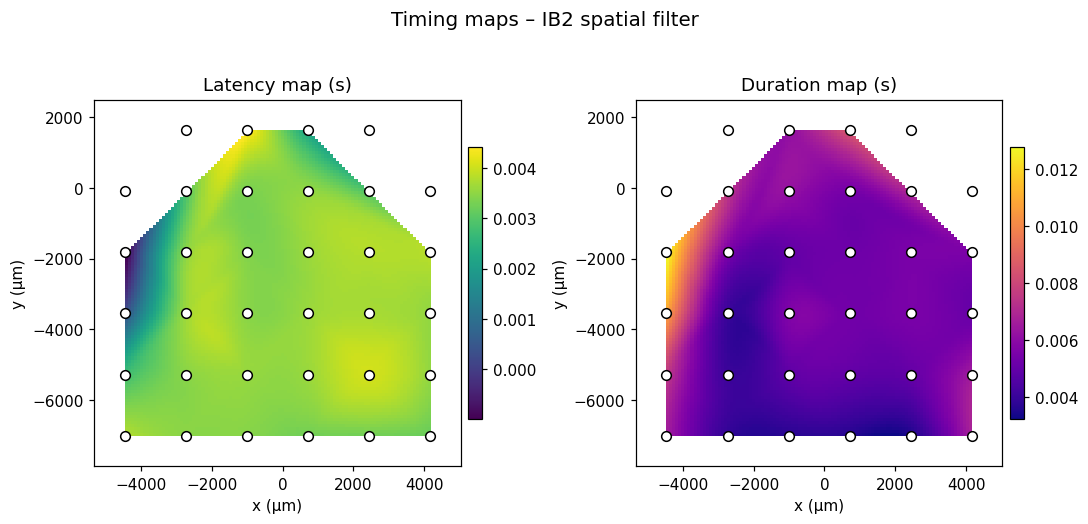

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

view_ib2.plot_eCMUAP_metric("latency",  T_PRE, T_POST,
                             skip_start=3, skip_end=3,
                             reject=True, cmap="viridis", ax=axes[0])
axes[0].set_title("Latency map (s)")

view_ib2.plot_eCMUAP_metric("duration", T_PRE, T_POST,
                             skip_start=3, skip_end=3,
                             reject=True, cmap="plasma", ax=axes[1])
axes[1].set_title("Duration map (s)")

plt.suptitle("Timing maps – IB2 spatial filter", fontsize=13)
plt.tight_layout()


## 9 · Summary

| Topic | API used |
|-------|---------|
| Load with probe | `Ripple_to_array`, `NeuroNexus_H32` |
| HD-EMG object | `HDEMG` |
| Uniform grid | `make_uniform_probe_from_base` |
| Spatial interpolation | `HDEMG.interpolate_to_probe` |
| Spatial filtering | `HDEMG.spatial_filter(kernel)` |
| Amplitude maps | `HDEMGView.plot_rms_map / plot_ptp_map` |
| Timing maps | `HDEMGView.plot_eCMUAP_metric` |

**Next:** [Notebook 3](03_conduction_velocity.ipynb) – propagation velocity, delay maps, and innervation zone.
